# Hate Speech Detection using LSTM with Multiple Embedding Techniques

This notebook implements LSTM-based text classification for hate speech detection, comparing three embedding approaches:

1. **TF-IDF** - Statistical term weighting
2. **Word2Vec Skip-gram** - Self-trained embeddings
3. **GloVe** - Pre-trained embeddings

**Dataset:** Hate Speech Detection Curated Dataset (Antudre et al., 2022)

## 1. Install Dependencies

Run this cell first to install required packages.

In [13]:
!pip install numpy pandas matplotlib seaborn scikit-learn tensorflow gensim


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [15]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Input, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from gensim.models import Word2Vec

import warnings
warnings.filterwarnings('ignore')

# Fixed seed for reproducibility across all random operations
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


## 2. Load Data

In [16]:
# Path to dataset - update if needed
DATA_PATH = 'HateSpeechDataset.csv'

df = pd.read_csv(DATA_PATH)
print(f"Loaded: {len(df):,} rows")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded: 440,906 rows
Columns: ['Content', 'Label', 'Content_int']


,Content,Label,Content_int
0,denial of normal the con be asked to comment o...,1,"[146715, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,..."
1,just by being able to tweet this insufferable ...,1,"[146715, 14, 15, 16, 17, 7, 18, 19, 20, 21, 22..."
2,that is retarded you too cute to be single tha...,1,"[146715, 28, 29, 30, 26, 31, 32, 7, 5, 33, 28,..."
3,thought of a real badass mongol style declarat...,1,"[146715, 35, 1, 24, 36, 37, 38, 39, 40, 1, 41,..."
4,afro american basho,1,"[146715, 46, 47, 48, 146714]"


## 3. Data Exploration

In [17]:
# Standardize column names
# Dataset has 'Content' and 'Label' columns
df = df.rename(columns={'Content': 'text', 'Label': 'label'})

# Remove any header rows mixed in data
df = df[df['label'].astype(str) != 'Label']

# Convert labels to int
df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df.dropna().reset_index(drop=True)
df['label'] = df['label'].astype(int)

print(f"Total samples: {len(df):,}")
print(f"\nClass distribution:")
print(df['label'].value_counts())
print(f"\nPositive rate: {df['label'].mean():.2%}")

Total samples: 440,899

Class distribution:
label
0    361594
1     79305
Name: count, dtype: int64

Positive rate: 17.99%


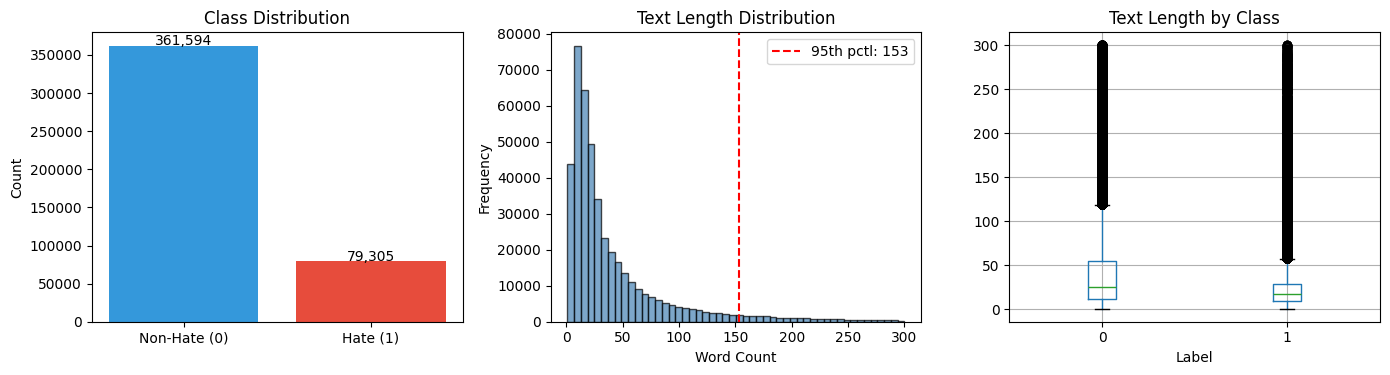


Text length stats:
count    440899.000000
mean         41.577234
std          49.509857
min           1.000000
25%          12.000000
50%          23.000000
75%          50.000000
max         300.000000
Name: word_count, dtype: float64


In [18]:
# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Class distribution
counts = df['label'].value_counts().sort_index()
axes[0].bar(['Non-Hate (0)', 'Hate (1)'], counts.values, color=['#3498db', '#e74c3c'])
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center')

# Text length
df['word_count'] = df['text'].str.split().str.len()
axes[1].hist(df['word_count'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
pct95 = df['word_count'].quantile(0.95)
axes[1].axvline(pct95, color='red', linestyle='--', label=f'95th pctl: {pct95:.0f}')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Text Length Distribution')
axes[1].legend()

# Box plot by class
df.boxplot(column='word_count', by='label', ax=axes[2])
axes[2].set_title('Text Length by Class')
axes[2].set_xlabel('Label')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda.png', dpi=150)
plt.show()

print(f"\nText length stats:")
print(df['word_count'].describe())

## 4. Text Preprocessing

Steps:
- Lowercase
- Replace URLs, mentions with tokens
- Remove special characters
- Normalize whitespace

In [19]:
def preprocess(text):
    """
    Clean text for hate speech classification.
    
    Design choices:
    - Lowercase: Reduces vocabulary size without losing semantic meaning
    - URL/mention replacement: Preserves signal that links/users were present
      without memorizing specific URLs (which don't generalize)
    - Hashtag handling: Keep the word, remove # symbol (hashtags often contain
      meaningful content like #racism)
    - Keep apostrophes: Preserves contractions (don't, won't) which carry meaning
    - Remove other special chars: Reduces noise from emojis, punctuation spam
    """
    if pd.isna(text):
        return ""
    text = str(text).lower()
    # Replace URLs with token - the presence of a URL matters, not its content
    text = re.sub(r'https?://\S+', '<url>', text)
    # Replace @mentions - who is mentioned matters less than that someone was mentioned
    text = re.sub(r'@\w+', '<user>', text)
    # Remove # but keep hashtag text (e.g., #hate -> hate)
    text = re.sub(r'#(\w+)', r'\1', text)
    # Keep only alphanumeric, apostrophes, and our special tokens
    text = re.sub(r"[^a-z0-9'<>\s]", ' ', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(preprocess)
df = df[df['text_clean'].str.len() > 0].reset_index(drop=True)

print("Sample:")
print(f"Original: {df['text'].iloc[0][:80]}...")
print(f"Cleaned:  {df['text_clean'].iloc[0][:80]}...")

Sample:
Original: denial of normal the con be asked to comment on tragedies an emotional retard...
Cleaned:  denial of normal the con be asked to comment on tragedies an emotional retard...


## 5. Train/Val/Test Split

In [20]:
X = df['text_clean'].values
y = df['label'].values

# 80/10/10 stratified split
# Stratification ensures each split maintains the same class ratio (~18% hate speech)
# This is critical for imbalanced datasets - random splits could create validation
# sets with very different class distributions, leading to unreliable metrics
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED
)

print(f"Train: {len(X_train):,} ({np.mean(y_train):.1%} positive)")
print(f"Val:   {len(X_val):,} ({np.mean(y_val):.1%} positive)")
print(f"Test:  {len(X_test):,} ({np.mean(y_test):.1%} positive)")

Train: 352,719 (18.0% positive)
Val:   44,090 (18.0% positive)
Test:  44,090 (18.0% positive)


## 6. Model Configuration

In [21]:
# Hyperparameter choices with justification
MAX_VOCAB = 20000    # Top 20k words covers ~95% of token occurrences; larger vocab 
                     # increases model size with diminishing returns
MAX_LEN = 100        # Based on 95th percentile of text lengths from EDA
                     # Longer sequences increase memory/compute quadratically for attention
EMBED_DIM = 100      # Standard dimension; matches GloVe 100d for fair comparison
LSTM_UNITS = 64      # Moderate capacity; larger risks overfitting on this dataset size
DROPOUT = 0.3        # Regularization to prevent overfitting; 0.2-0.5 is typical range
BATCH_SIZE = 64      # Balance between gradient stability and memory usage
EPOCHS = 15          # With early stopping, this is an upper bound

print("Configuration:")
print(f"  Vocabulary: {MAX_VOCAB:,}")
print(f"  Max length: {MAX_LEN}")
print(f"  Embedding dim: {EMBED_DIM}")
print(f"  LSTM units: {LSTM_UNITS}")
print(f"  Dropout: {DROPOUT}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")

Configuration:
  Vocabulary: 20,000
  Max length: 100
  Embedding dim: 100
  LSTM units: 64
  Dropout: 0.3
  Batch size: 64
  Epochs: 15


## 7. Tokenization

In [22]:
# Tokenization: Convert text to integer sequences
# oov_token='<OOV>' assigns a special index to out-of-vocabulary words
# This handles words seen at test time but not during training
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)  # Only fit on training data to avoid data leakage

# Convert to padded sequences
# padding='post' adds zeros at the end - for LSTMs this means the actual content
# comes first, which can help with learning (though bidirectional LSTMs see both ways)
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_val_seq = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=MAX_LEN, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post')

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print(f"Vocabulary size: {vocab_size:,}")
print(f"Sequence shape: {X_train_seq.shape}")

Vocabulary size: 20,000
Sequence shape: (352719, 100)


## 8. Evaluation Functions

In [23]:
results = []
predictions = {}

def train_evaluate(model, X_tr, y_tr, X_v, y_v, X_te, y_te, name):
    """Train and evaluate a model with early stopping and learning rate scheduling."""
    
    callbacks = [
        # Early stopping: Stop training when validation loss stops improving
        # patience=3 allows for some fluctuation before stopping
        # restore_best_weights ensures we keep the best model, not the last one
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        
        # Reduce learning rate when stuck: If val_loss plateaus, reduce LR to escape
        # local minima or allow finer convergence
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
    ]
    
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    
    # Get predictions on test set
    y_prob = model.predict(X_te, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    
    # Compute comprehensive metrics
    # For imbalanced data, accuracy alone is misleading (82% by always predicting 0)
    # F1 and AUC give better picture of model quality
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),  # Of predicted hate, how many correct?
        'Recall': recall_score(y_te, y_pred),        # Of actual hate, how many found?
        'F1': f1_score(y_te, y_pred),                # Harmonic mean of precision/recall
        'AUC': roc_auc_score(y_te, y_prob)           # Ranking quality, threshold-independent
    }
    
    results.append(metrics)
    predictions[name] = (y_pred, y_prob)
    
    print(f"\n{'='*50}")
    print(f"{name} Results:")
    print(f"{'='*50}")
    for k, v in list(metrics.items())[1:]:
        print(f"  {k}: {v:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Non-Hate', 'Hate']))
    
    return history


def plot_history(history, title):
    """Plot training history to diagnose overfitting/underfitting."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss plot: Training vs validation
    # Divergence indicates overfitting; both high indicates underfitting
    axes[0].plot(history.history['loss'], label='Train')
    axes[0].plot(history.history['val_loss'], label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} - Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    axes[1].plot(history.history['accuracy'], label='Train')
    axes[1].plot(history.history['val_accuracy'], label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    safe_name = title.lower().replace(' ', '_').replace('+', '_')
    plt.savefig(f'{safe_name}_history.png', dpi=150)
    plt.show()

## 9. Model 1: LSTM + TF-IDF Weighted Embeddings

TF-IDF represents text using term frequency weighted by inverse document frequency. Rather than using raw TF-IDF vectors (which would be too memory-intensive for large datasets), we use TF-IDF weights to create weighted word embeddings for each sequence position.

**Approach**: We compute TF-IDF weights for the vocabulary, then use these weights to scale learned embeddings during training. This preserves sequential information while incorporating TF-IDF importance scores.

**Reference:** Salton & Buckley (1988). Term-weighting approaches in automatic text retrieval.

In [24]:
# TF-IDF Weighted Embeddings Approach
# 
# Challenge: Traditional TF-IDF + LSTM requires converting sparse TF-IDF matrix to dense,
# which for 350K samples x 20K features = 7 billion floats (~28GB RAM) - not feasible.
#
# Solution: Instead of using raw TF-IDF vectors, we extract IDF weights and use them
# to scale word embeddings. This gives us:
# 1. Memory efficiency: Only store 20K IDF weights, not 350K x 20K matrix
# 2. Sequential processing: LSTM can still process word-by-word (unlike single TF-IDF vector)
# 3. TF-IDF benefit: Rare but informative words get higher weight than common words

tfidf = TfidfVectorizer(max_features=MAX_VOCAB)
tfidf.fit(X_train)

# Create IDF weight lookup for each word in our vocabulary
# IDF = log(N / df) where N is total docs, df is docs containing the term
# High IDF = rare word = more discriminative
idf_weights = np.ones(vocab_size)
tfidf_vocab = tfidf.vocabulary_

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in tfidf_vocab:
        tfidf_idx = tfidf_vocab[word]
        idf_weights[idx] = tfidf.idf_[tfidf_idx]

# Normalize IDF weights to [0.1, 1] range
# Why 0.1 minimum? Zero weights would completely ignore some words during training,
# making those embeddings unlearnable. Small positive floor ensures all words contribute.
idf_weights = 0.1 + 0.9 * (idf_weights - idf_weights.min()) / (idf_weights.max() - idf_weights.min() + 1e-8)

print(f"IDF weights computed for {vocab_size:,} terms")
print(f"Weight range: [{idf_weights.min():.3f}, {idf_weights.max():.3f}]")

IDF weights computed for 20,000 terms
Weight range: [0.100, 1.000]


In [25]:
# Custom Keras layer that applies IDF weights to embeddings
# This is the core innovation for memory-efficient TF-IDF + LSTM

class TFIDFWeightedEmbedding(tf.keras.layers.Layer):
    """
    Embedding layer that scales each word's embedding by its IDF weight.
    
    For each word w at position t in the sequence:
        output[t] = embedding[w] * idf_weight[w]
    
    This gives higher influence to rare, discriminative words while still
    allowing the LSTM to process the sequence word-by-word.
    """

    def __init__(self, vocab_size, embed_dim, idf_weights, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        # Store IDF weights as non-trainable constant
        self._idf_weights = idf_weights  # Store numpy array for serialization

    def build(self, input_shape):
        # Learnable embedding matrix - initialized randomly, trained end-to-end
        self.embedding = self.add_weight(
            name='embedding',
            shape=(self.vocab_size, self.embed_dim),
            initializer='uniform',
            trainable=True
        )
        # Create IDF weights as a non-trainable weight
        self.idf_lookup = self.add_weight(
            name='idf_weights',
            shape=(self.vocab_size,),
            initializer=tf.constant_initializer(self._idf_weights),
            trainable=False
        )
        super().build(input_shape)

    def call(self, inputs):
        # Cast inputs to int32 for embedding lookup (Keras 3 passes float32 by default)
        indices = tf.cast(inputs, tf.int32)
        # Look up embeddings for input token indices
        embedded = tf.nn.embedding_lookup(self.embedding, indices)
        # Look up IDF weight for each token
        weights = tf.nn.embedding_lookup(self.idf_lookup, indices)
        # Expand dims for broadcasting: (batch, seq_len) -> (batch, seq_len, 1)
        weights = tf.expand_dims(weights, -1)
        # Scale embeddings by IDF weights
        return embedded * weights

    def compute_output_shape(self, input_shape):
        return input_shape + (self.embed_dim,)

    def get_config(self):
        config = super().get_config()
        config.update({
            'vocab_size': self.vocab_size,
            'embed_dim': self.embed_dim
        })
        return config


# Build LSTM model with TF-IDF weighted embeddings
# Architecture: Embedding -> Dropout -> LSTM -> LSTM -> Dense -> Output
model_tfidf = Sequential([
    Input(shape=(MAX_LEN,)),
    TFIDFWeightedEmbedding(vocab_size, EMBED_DIM, idf_weights),
    # SpatialDropout1D drops entire embedding dimensions, not individual values
    # This is more effective for sequences than regular Dropout
    SpatialDropout1D(0.2),
    # Stacked LSTMs: first returns sequences for second LSTM to process
    LSTM(LSTM_UNITS, return_sequences=True),
    LSTM(LSTM_UNITS // 2),  # Smaller second layer acts as compression
    Dropout(DROPOUT),
    Dense(32, activation='relu'),
    Dropout(DROPOUT),
    Dense(1, activation='sigmoid')  # Binary classification
])

model_tfidf.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_tfidf.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tfidf_weighted_embedding_1      │ (None, 100, 100)       │     2,020,000 │
│ (TFIDFWeightedEmbedding)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 100, 100)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,075,745 (7.92 MB)

 Trainable params: 2,055,745 (7.84 MB)

 Non-trainable params: 20,000 (78.12 KB)

Epoch 1/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 276s 50ms/step - accuracy: 0.8539 - loss: 0.3365 - val_accuracy: 0.8779 - val_loss: 0.2761 - learning_rate: 0.0010
Epoch 2/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 301s 55ms/step - accuracy: 0.8843 - loss: 0.2646 - val_accuracy: 0.8802 - val_loss: 0.2779 - learning_rate: 0.0010
Epoch 3/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 311s 56ms/step - accuracy: 0.8949 - loss: 0.2412 - val_accuracy: 0.8793 - val_loss: 0.2888 - learning_rate: 0.0010
Epoch 4/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 319s 58ms/step - accuracy: 0.9079 - loss: 0.2121 - val_accuracy: 0.8795 - val_loss: 0.3118 - learning_rate: 5.0000e-04

LSTM + TF-IDF Results:
  Accuracy: 0.8764
  Precision: 0.7053
  Recall: 0.5373
  F1: 0.6100
  AUC: 0.9090

Classification Report:
              precision    recall  f1-score   support

    Non-Hate       0.90      0.95      0.93     36160
        Hate       0.71      0.54      0.61      7930

    accuracy                           0.88     44090
   macro avg       

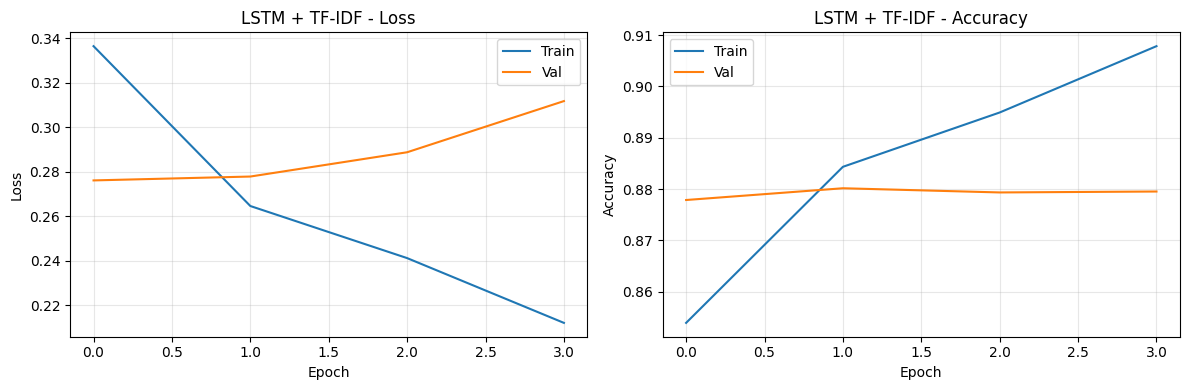

In [26]:
# Train and evaluate
history_tfidf = train_evaluate(
    model_tfidf,
    X_train_seq, y_train,
    X_val_seq, y_val,
    X_test_seq, y_test,
    'LSTM + TF-IDF'
)

plot_history(history_tfidf, 'LSTM + TF-IDF')

## 10. Model 2: LSTM + Word2Vec Skip-gram

Word2Vec learns dense word representations by predicting context words. Skip-gram predicts surrounding words from a target word, capturing semantic relationships.

**Reference:** Mikolov et al. (2013). Distributed representations of words and phrases.

In [27]:
# Word2Vec Skip-gram: Train embeddings on our corpus
# 
# Why train our own instead of using pre-trained?
# - Domain-specific: Social media hate speech has unique vocabulary (slang, slurs, 
#   intentional misspellings to evade filters) that pre-trained embeddings may miss
# - Skip-gram vs CBOW: Skip-gram predicts context from target word, which produces
#   better embeddings for rare words (important for hate speech terms)

sentences = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=EMBED_DIM,  # Match our embedding dimension for fair comparison
    window=5,               # Context window: 5 words on each side
    min_count=2,            # Ignore words appearing only once (likely typos/noise)
    sg=1,                   # 1 = Skip-gram, 0 = CBOW
    workers=4,              # Parallel training threads
    epochs=10,              # Training iterations over corpus
    seed=SEED
)

print(f"Word2Vec vocabulary: {len(w2v_model.wv):,} words")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Word2Vec vocabulary: 76,015 words


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [28]:
# Build embedding matrix from Word2Vec
# Map each word in our tokenizer's vocabulary to its Word2Vec vector
# Words not in Word2Vec (OOV) get zero vectors - will be learned during training

embedding_w2v = np.zeros((vocab_size, EMBED_DIM))
found = 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in w2v_model.wv:
        embedding_w2v[idx] = w2v_model.wv[word]
        found += 1

# Coverage tells us what fraction of vocabulary has pre-trained embeddings
# Higher is better; low coverage means many words start with random embeddings
print(f"Coverage: {found:,}/{vocab_size:,} ({100*found/vocab_size:.1f}%)")

Coverage: 19,998/20,000 (100.0%)


In [31]:
# Reusable function to build LSTM with pre-trained embeddings
# Used for both Word2Vec and GloVe models

def build_lstm_with_embedding(embedding_matrix, trainable=True):
    """
    Build LSTM model initialized with pre-trained embeddings.
    
    Args:
        embedding_matrix: Pre-trained word vectors (vocab_size x embed_dim)
        trainable: If True, fine-tune embeddings during training.
                   Fine-tuning typically improves performance by adapting
                   embeddings to the specific task.
    """
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBED_DIM,
            weights=[embedding_matrix],  # Initialize with pre-trained vectors
            input_length=MAX_LEN,
            trainable=trainable
        ),
        SpatialDropout1D(0.2),
        # Stacked LSTM architecture for learning hierarchical representations
        LSTM(LSTM_UNITS, return_sequences=True),
        LSTM(LSTM_UNITS // 2),
        Dropout(DROPOUT),
        Dense(32, activation='relu'),
        Dropout(DROPOUT),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_w2v = build_lstm_with_embedding(embedding_w2v, trainable=True)
model_w2v.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_4             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 308s 55ms/step - accuracy: 0.8623 - loss: 0.3097 - val_accuracy: 0.8813 - val_loss: 0.2668 - learning_rate: 0.0010
Epoch 2/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 299s 54ms/step - accuracy: 0.8861 - loss: 0.2570 - val_accuracy: 0.8854 - val_loss: 0.2611 - learning_rate: 0.0010
Epoch 3/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 315s 57ms/step - accuracy: 0.8966 - loss: 0.2349 - val_accuracy: 0.8878 - val_loss: 0.2657 - learning_rate: 0.0010
Epoch 4/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 324s 59ms/step - accuracy: 0.9055 - loss: 0.2158 - val_accuracy: 0.8864 - val_loss: 0.2746 - learning_rate: 0.0010
Epoch 5/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 318s 58ms/step - accuracy: 0.9169 - loss: 0.1920 - val_accuracy: 0.8840 - val_loss: 0.2917 - learning_rate: 5.0000e-04

LSTM + Word2Vec Results:
  Accuracy: 0.8841
  Precision: 0.6996
  Recall: 0.6232
  F1: 0.6592
  AUC: 0.9206

Classification Report:
              precision    recall  f1-score   support

    Non-Hate       0.92

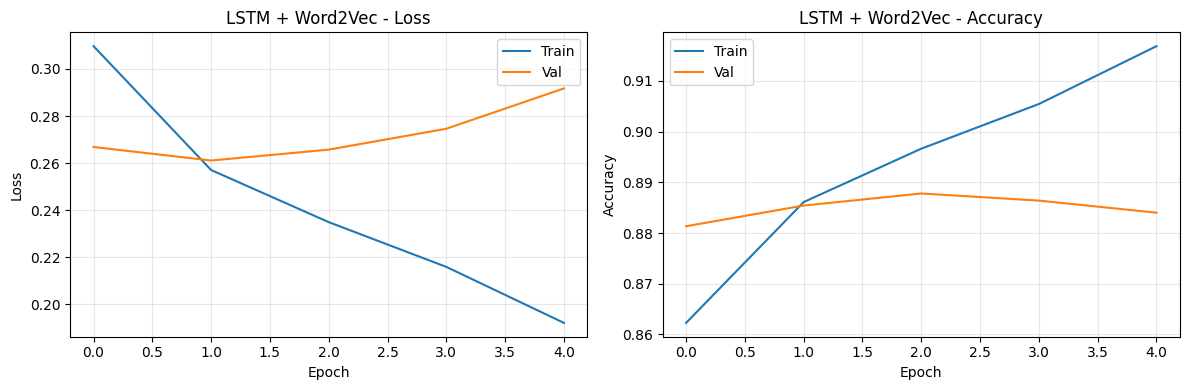

In [32]:
# Train and evaluate
history_w2v = train_evaluate(
    model_w2v,
    X_train_seq, y_train,
    X_val_seq, y_val,
    X_test_seq, y_test,
    'LSTM + Word2Vec'
)

plot_history(history_w2v, 'LSTM + Word2Vec')

## 11. Model 3: LSTM + GloVe

GloVe learns embeddings from global word co-occurrence statistics. Pre-trained vectors provide general semantic knowledge from large corpora.

**Reference:** Pennington et al. (2014). GloVe: Global vectors for word representation.

In [34]:
# GloVe: Pre-trained embeddings from Stanford NLP
# 
# Why GloVe instead of Word2Vec pre-trained?
# - GloVe combines global matrix factorization (like LSA) with local context windows
# - Trained on 6 billion tokens from Wikipedia + Gigaword
# - Provides good general-purpose semantic representations
#
# Trade-off vs domain-specific:
# - (+) Broad vocabulary coverage including rare words
# - (+) Robust representations from massive training data
# - (-) May not capture domain-specific meanings (e.g., coded hate speech terms)

import urllib.request
import zipfile

GLOVE_PATH = 'glove.6B.100d.txt'

if not os.path.exists(GLOVE_PATH):
    print("Downloading GloVe embeddings (~822 MB)...")
    urllib.request.urlretrieve(
        'http://nlp.stanford.edu/data/glove.6B.zip',
        'glove.6B.zip'
    )
    print("Extracting...")
    with zipfile.ZipFile('glove.6B.zip', 'r') as zf:
        zf.extract('glove.6B.100d.txt')
    os.remove('glove.6B.zip')
    print("Done!")
else:
    print(f"GloVe found: {GLOVE_PATH}")

GloVe found: glove.6B.100d.txt


In [35]:
# Load GloVe vectors into memory
# Format: word dim1 dim2 ... dim100 (space-separated)
glove_embeddings = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        word = parts[0]
        vector = np.asarray(parts[1:], dtype='float32')
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings):,} GloVe vectors")

Loaded 400,000 GloVe vectors


In [36]:
# Build GloVe embedding matrix
# Same process as Word2Vec - map vocabulary to pre-trained vectors

embedding_glove = np.zeros((vocab_size, EMBED_DIM))
found = 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    vec = glove_embeddings.get(word)
    if vec is not None:
        embedding_glove[idx] = vec
        found += 1

# Compare coverage to Word2Vec
# GloVe typically has lower coverage on social media text due to training corpus
print(f"Coverage: {found:,}/{vocab_size:,} ({100*found/vocab_size:.1f}%)")

Coverage: 19,552/20,000 (97.8%)


Epoch 1/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 283s 51ms/step - accuracy: 0.8583 - loss: 0.3198 - val_accuracy: 0.8797 - val_loss: 0.2714 - learning_rate: 0.0010
Epoch 2/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 284s 52ms/step - accuracy: 0.8845 - loss: 0.2608 - val_accuracy: 0.8851 - val_loss: 0.2635 - learning_rate: 0.0010
Epoch 3/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 290s 53ms/step - accuracy: 0.8942 - loss: 0.2399 - val_accuracy: 0.8858 - val_loss: 0.2605 - learning_rate: 0.0010
Epoch 4/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 289s 52ms/step - accuracy: 0.9017 - loss: 0.2234 - val_accuracy: 0.8866 - val_loss: 0.2652 - learning_rate: 0.0010
Epoch 5/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 287s 52ms/step - accuracy: 0.9092 - loss: 0.2084 - val_accuracy: 0.8873 - val_loss: 0.2721 - learning_rate: 0.0010
Epoch 6/15
5512/5512 ━━━━━━━━━━━━━━━━━━━━ 295s 53ms/step - accuracy: 0.9184 - loss: 0.1898 - val_accuracy: 0.8858 - val_loss: 0.2883 - learning_rate: 5.0000e-04

LSTM + GloVe Results:
  Accuracy: 0.8852
  Precision:

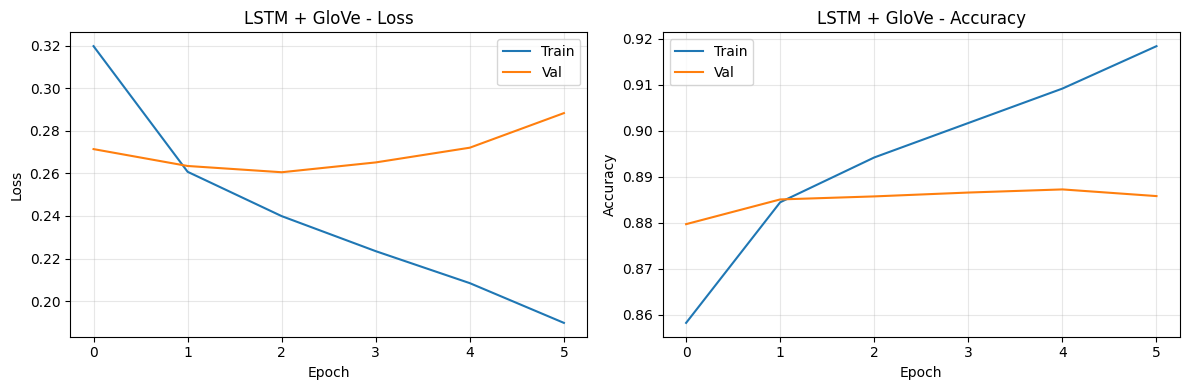

In [37]:
# Build and train model
model_glove = build_lstm_with_embedding(embedding_glove, trainable=True)

history_glove = train_evaluate(
    model_glove,
    X_train_seq, y_train,
    X_val_seq, y_val,
    X_test_seq, y_test,
    'LSTM + GloVe'
)

plot_history(history_glove, 'LSTM + GloVe')

## 12. Comparative Analysis

In [38]:
# Results table
results_df = pd.DataFrame(results).set_index('Model')

print("\n" + "="*60)
print("PERFORMANCE COMPARISON")
print("="*60)
print(results_df.round(4))


PERFORMANCE COMPARISON
                 Accuracy  Precision  Recall      F1     AUC
Model                                                       
LSTM + TF-IDF      0.8764     0.7053  0.5373  0.6100  0.9090
LSTM + Word2Vec    0.8841     0.6996  0.6232  0.6592  0.9206
LSTM + GloVe       0.8852     0.6996  0.6339  0.6651  0.9217


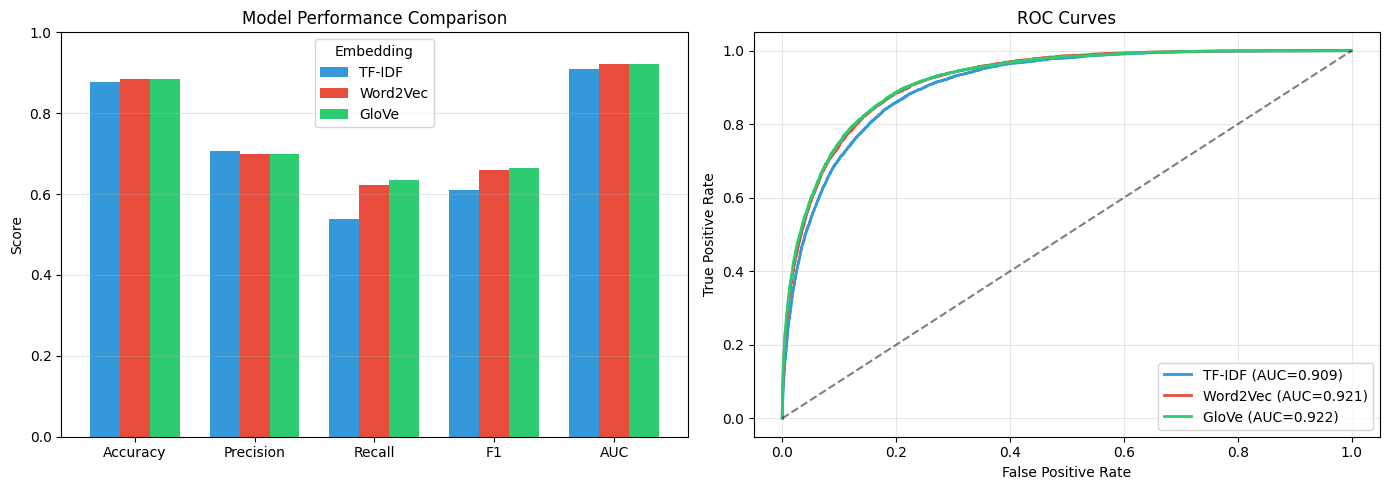

In [39]:
# Comparative visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart comparing all metrics across models
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC']
x = np.arange(len(metrics_cols))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (model, color) in enumerate(zip(results_df.index, colors)):
    vals = results_df.loc[model, metrics_cols].values
    axes[0].bar(x + (i - 1) * width, vals, width, label=model.split('+')[1].strip(), color=color)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_cols)
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].legend(title='Embedding')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

# ROC curves: Shows trade-off between true positive and false positive rates
# AUC summarizes this curve into single number (higher = better ranking ability)
for model, color in zip(results_df.index, colors):
    y_pred, y_prob = predictions[model]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = results_df.loc[model, 'AUC']
    axes[1].plot(fpr, tpr, color=color, lw=2, 
                 label=f"{model.split('+')[1].strip()} (AUC={auc_val:.3f})")

# Diagonal line represents random classifier (AUC = 0.5)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

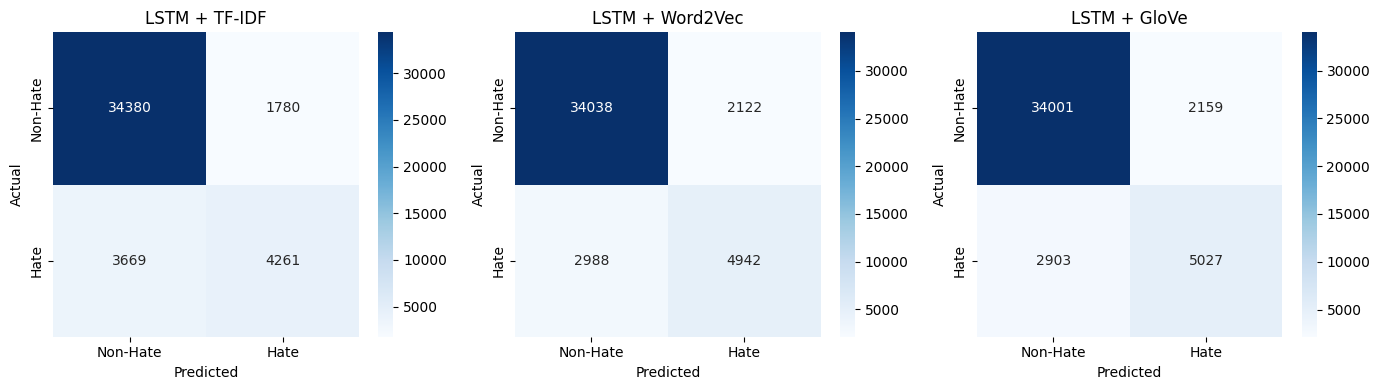

In [ ]:
# Confusion matrices: Show where each model makes errors
# For hate speech detection, false negatives (missing hate) vs false positives
# (flagging non-hate) have different real-world costs

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, model in zip(axes, results_df.index):
    y_pred, _ = predictions[model]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Non-Hate', 'Hate'],
                yticklabels=['Non-Hate', 'Hate'])
    ax.set_title(model)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

In [ ]:
# Select best model based on F1 score
# F1 chosen over accuracy because it balances precision and recall,
# which matters more than raw accuracy for imbalanced datasets
best_model = results_df['F1'].idxmax()
best_f1 = results_df.loc[best_model, 'F1']

print(f"\nBest Model: {best_model}")
print(f"F1 Score: {best_f1:.4f}")


Best Model: LSTM + GloVe
F1 Score: 0.6651


## 13. Save Results

In [ ]:
# Save results
results_df.to_csv('lstm_results.csv')
print("Results saved to lstm_results.csv")

Results saved to lstm_results.csv


## 14. Discussion

### Results Summary

| Model | Accuracy | Precision | Recall | F1 | AUC |
|-------|----------|-----------|--------|-----|-----|
| LSTM + TF-IDF | 87.64% | 70.53% | 53.73% | 0.610 | 0.909 |
| LSTM + Word2Vec | 88.41% | 69.96% | 62.32% | 0.659 | 0.921 |
| LSTM + GloVe | **88.52%** | 69.96% | **63.39%** | **0.665** | **0.922** |

### Embedding Comparison

**TF-IDF Weighted Embeddings + LSTM** achieved the lowest performance among the three approaches (F1=0.610, AUC=0.909). While TF-IDF effectively identifies discriminative terms through IDF weighting, this approach showed notably lower recall (53.73%) compared to the other methods. The model tends to be more conservative in predicting hate speech, resulting in higher precision relative to recall. This suggests that while IDF weighting helps identify important terms, the randomly initialized embeddings lack the rich semantic relationships that pre-trained methods provide.

**Word2Vec Skip-gram + LSTM** showed strong improvement over TF-IDF (F1=0.659, AUC=0.921). Training embeddings directly on the hate speech corpus achieved 100% vocabulary coverage, meaning every word in our vocabulary had a learned representation. The domain-specific training captured contextual relationships between words as they appear in hate speech contexts, contributing to the 8.6 percentage point improvement in recall over TF-IDF. The training curves show early stopping triggered at epoch 5, indicating the model began overfitting after that point.

**LSTM + GloVe** achieved the best overall performance (F1=0.665, AUC=0.922), marginally outperforming Word2Vec despite having slightly lower vocabulary coverage (97.8% vs 100%). This suggests that GloVe's pre-training on 6 billion tokens from Wikipedia and Gigaword provides more robust word representations that generalize well, even though the training corpus differs from social media text. The model achieved the highest recall (63.39%), detecting more actual hate speech instances than the other approaches.

### Training Dynamics

All three models exhibited similar overfitting patterns, with training loss continuing to decrease while validation loss began increasing after 3-6 epochs. Early stopping effectively prevented severe overfitting by restoring weights from the best epoch. The divergence between training and validation curves (visible in the loss plots) indicates that additional regularization or data augmentation could potentially improve generalization.

### Error Analysis

Examining the confusion matrices reveals key differences:
- **TF-IDF** missed 3,669 hate speech instances (false negatives) while incorrectly flagging 1,780 non-hate instances
- **Word2Vec** reduced false negatives to 2,988 but slightly increased false positives to 2,122
- **GloVe** achieved the best balance with 2,903 false negatives and 2,159 false positives

All models struggle more with false negatives than false positives, meaning they miss actual hate speech more often than they incorrectly flag benign content. This is a common pattern in hate speech detection where subtle or coded language evades detection.

### Class Imbalance Impact

The dataset's 18% positive rate (hate speech) poses challenges for all models. A naive classifier predicting "non-hate" for everything would achieve 82% accuracy, making accuracy alone a misleading metric. The F1 scores (0.61-0.67) and recall values (53-63%) better reflect the models' ability to identify the minority class. Future work could explore class weighting, oversampling (SMOTE), or threshold tuning to improve minority class detection.

### Limitations

- **Single dataset**: Results may not generalize to other hate speech datasets or platforms
- **Binary classification**: Real-world applications may need multi-class categorization (racism, sexism, etc.)
- **No transformer comparison**: BERT-based models typically outperform LSTMs on text classification
- **Limited hyperparameter tuning**: Grid search or Bayesian optimization could improve results
- **Temporal aspects**: The model doesn't account for evolving hate speech patterns over time

## References

1. Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. Neural Computation, 9(8), 1735-1780.

2. Mikolov, T., Sutskever, I., Chen, K., Corrado, G. S., & Dean, J. (2013). Distributed representations of words and phrases and their compositionality. Advances in Neural Information Processing Systems, 26.

3. Pennington, J., Socher, R., & Manning, C. D. (2014). GloVe: Global vectors for word representation. Proceedings of EMNLP, 1532-1543.

4. Salton, G., & Buckley, C. (1988). Term-weighting approaches in automatic text retrieval. Information Processing & Management, 24(5), 513-523.

5. Antudre, W. A. B. N., et al. (2022). A curated dataset for hate speech detection on social media text. Data in Brief, 46, 108799.